In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm 

from qick import *
# for now, all the tProc v2 classes need to be individually imported (can't use qick.*)
# the main program class
from qick.asm_v2 import AveragerProgramV2
# for defining sweeps
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.pyro import make_proxy
soc, soccfg = make_proxy(ns_host="192.168.10.82", ns_port=8888, proxy_name="myqick")
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_147102fb8ef64e159d6625457207e18f@192.168.10.82:36589
QICK running on ZCU216, software version 0.2.367

Firmware configuration (built Fri Sep 13 20:50:31 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

In [11]:
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        if soccfg['gens'][gen_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=gen_ch, nqz=2, mixer_freq=cfg['freq'], ro_ch=ro_ch)
        else:
            self.declare_gen(ch=gen_ch, nqz=2, ro_ch=ro_ch)
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)
        self.add_gauss(ch=gen_ch, name='ramp', sigma=0.01, length=0.01*4)
        self.add_pulse(ch=gen_ch, name="myconst", ro_ch=ro_ch, 
                    #    style="const", 
                       style="flat_top", 
                       envelope='ramp',
                       length=cfg['pulse_len'], 
                       freq=cfg['freq'], 
                       phase=cfg['pulse_phase'],
                       gain=cfg['pulse_gain'],
                      )
        

        
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['gen_ch'], name="myconst", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)


config = {
    ## Channel Params. ##
    'gen_ch': 8,
    'ro_ch': 0,
    ## Pulse Params. ##
    'freq': 5000, # [MHz]
    'pulse_len': 1, # [us]
    'pulse_phase': 0, # [deg]
    'pulse_gain': 1, # [DAC units]
    ## Readout Params. ##
    'trig_time': 0, # [us]
    'ro_len': 3, # [us]
    'relax_delay': 0.1, # [us]
     }

###################
# Run the Program
###################

prog =LoopbackProgram(soccfg, reps=1, final_delay=config['relax_delay'], cfg=config)
iq_list1 = prog.acquire_decimated(soc, rounds=1)
iq_list2 = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

Envelope length 17 is an odd number of fabric cycles.
The middle cycle of the envelope will not be used.
If this is a problem, you could use the even_length parameter for your envelope.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
iq_list3 = prog.acquire_decimated(soc, rounds=1)

  0%|          | 0/1 [00:00<?, ?it/s]

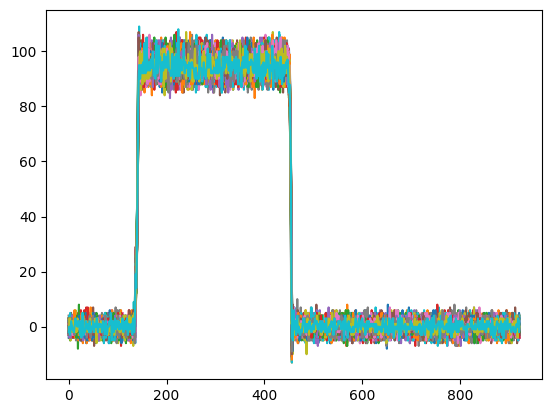

In [ ]:
for i in range(100):
    iq_list = prog.acquire_decimated(soc, rounds=1, progress=False)
    plt.plot(iq_list[0].T[0])
    plt.plot(iq_list[0].T[0])


In [140]:
from single_qubit_pyscrip_v1_3.async_fun import asyn_run
import plotly.graph_objects as go
py_avg = 1000

prog =LoopbackProgram(soccfg, reps=1, final_delay=config['relax_delay'], cfg=config)
figw = go.FigureWidget(
    data=[go.Scatter(x=t, y=np.zeros_like(t), mode="lines+markers", name="|IQ|")]
)


t = prog.get_time_axis(ro_index=0)

figw.update_layout(title=f"average: 0 / {py_avg}",
                xaxis_title="Time (us)",
                yaxis_title="ADC unit")
display(figw)


iq_list = await asyn_run(prog, soc, py_avg, figw, title="TOF", mode="decimate")

Envelope length 17 is an odd number of fabric cycles.
The middle cycle of the envelope will not be used.
If this is a problem, you could use the even_length parameter for your envelope.


FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': '|IQ|',
              'type': 'scatter',
              'uid': '4e0540fe-b52f-431f-bd71-0cdc0c72d5f6',
              'x': array([0.        , 0.00325521, 0.00651042, ..., 2.99153646, 2.99479167,
                          2.99804688]),
              'y': array([0., 0., 0., ..., 0., 0., 0.])}],
    'layout': {'template': '...',
               'title': {'text': 'average: 0 / 1000'},
               'xaxis': {'title': {'text': 'Time (us)'}},
               'yaxis': {'title': {'text': 'ADC unit'}}}
})

average count:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# import asyncio
# import numpy as np
# import plotly.graph_objects as go
# from IPython.display import display
# from tqdm.notebook import tqdm

# py_avg = 1000
# update_interval = 2  # Update every 5 averages to avoid too frequent refresh

# # Initialize empty plot
# figw = go.FigureWidget(
#     data=[go.Scatter(x=t, y=[], mode="lines+markers", name="|IQ|")]
# )
# figw.update_layout(
#     title=f"average: 0 / {py_avg}",
#     xaxis_title="Sample index",
#     yaxis_title="|IQ|",
#     autosize=True,
#     margin=dict(l=10, r=10, t=30, b=30, pad=0),
#     transition={'duration': 0},   # 🚀 Disable animation
# )
# figw.update_traces(line=dict(simplify=True))  # 🚀 Simplify line rendering
# display(figw)

# async def acquire_data(program, queue: asyncio.Queue, stop_event: asyncio.Event, latest_holder: dict, mode: str):
#     """Acquire IQ data (decimate or normal) and update averages"""
#     iq_sum = None

#     # Select acquisition function depending on mode
#     if mode == 'decimate':
#         acquire_fn = program.acquire_decimated
#     else:
#         acquire_fn = program.acquire

#     try:
#         for i in tqdm(range(py_avg), desc="average count"):
#             iq = acquire_fn(soc, rounds=1, progress=False)[0]  # unified call
#             iq_complex = iq.dot([1, 1j])

#             if iq_sum is None:
#                 iq_sum = np.zeros_like(iq_complex, dtype=complex)

#             iq_sum += iq_complex
#             iq_avg = iq_sum / (i + 1)

#             # Store latest values
#             latest_holder["iq_avg"] = iq_avg
#             y_plot = np.abs(iq_avg)
#             latest_holder["y_plot"] = y_plot

#             # Keep only the newest value in queue
#             if queue.full():
#                 _ = queue.get_nowait()
#             await queue.put((i + 1, y_plot))

#             await asyncio.sleep(0)
#     except Exception as e:
#         print(f"[acquire] Instrument stopped: {e}")
#     finally:
#         stop_event.set()
#         # Clear queue before exit
#         while not queue.empty():
#             _ = queue.get_nowait()
#         await queue.put(None)



# async def plot_data(queue: asyncio.Queue, stop_event: asyncio.Event, latest_holder: dict, mode: str):
#     """Update plot with the data coming from queue"""
#     if mode == 'decimate':
#         while not stop_event.is_set():
#             if queue.empty():
#                 await asyncio.sleep(0.05)
#                 continue

#             item = await queue.get()
#             if item is None:
#                 break

#             i, y_plot = item
#             # 🚀 Update plot only every update_interval steps
#             if (i % update_interval == 0) or (i == py_avg):
#                 with figw.batch_update():
#                     figw.data[0].y = y_plot
#                     figw.layout.title.text = f"average: {i} / {py_avg}"
#                 latest_holder["y_plot"] = y_plot  # 👉 Ensure last frame is stored


# async def main(program, mode):
#     """Run acquisition + plotting, return final iq_avg"""
#     queue = asyncio.Queue(maxsize=1)
#     stop_event = asyncio.Event()
#     latest_holder = {"iq_avg": None, "y_plot": None}

#     task1 = asyncio.create_task(acquire_data(program, queue, stop_event, latest_holder, mode=mode))
#     task2 = asyncio.create_task(plot_data(queue, stop_event, latest_holder, mode=mode))

#     try:
#         await asyncio.gather(task1, task2)
#     except asyncio.CancelledError:
#         print("⚠️ Measurement interrupted, freezing last y_plot")
#     finally:
#         # 👉 Freeze final plot at the last y_plot
#         if latest_holder["y_plot"] is not None:
#             with figw.batch_update():
#                 figw.data[0].x = np.arange(len(latest_holder["y_plot"]))
#                 figw.data[0].y = latest_holder["y_plot"]
#                 figw.layout.title.text = f"Plot"
#         return latest_holder["iq_avg"]


# # Run in Jupyter notebook
# iq_avg_final = await main(prog, mode='decimate')
# print("Returned iq_avg shape:", iq_avg_final.shape if iq_avg_final is not None else None)


FigureWidget({
    'data': [{'line': {'simplify': True},
              'mode': 'lines+markers',
              'name': '|IQ|',
              'type': 'scatter',
              'uid': 'ed46b77e-f53c-4986-a67b-ac184cc87cf3',
              'x': array([0.        , 0.00325521, 0.00651042, ..., 2.99153646, 2.99479167,
                          2.99804688]),
              'y': []}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 30},
               'template': '...',
               'title': {'text': 'average: 0 / 1000'},
               'transition': {'duration': 0},
               'xaxis': {'title': {'text': 'Sample index'}},
               'yaxis': {'title': {'text': '|IQ|'}}}
})

average count:   0%|          | 0/1000 [00:00<?, ?it/s]

Returned iq_avg shape: (922,)


In [83]:

r1 = 5895
r2 = 6059
r3 = 5958
r4 = 6100
r5 = 5995


r = [r1, r2, r3, r4, r5, r5]
res_mixer = round(np.sum(r)/6)
res_mixer=5800
q1, q2, q3, q4, q5 = [2, 7, 5, 7, 0]
q = [q1, q2, q3, q4, q5]
config = {'res_ch': 4,
          'ro_chs': [2, 3, 4, 5, 6,7],
          'res_freqs': r,
          'mixer_freq': res_mixer,
          'res_gains': [0.3]*6,
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 2,
          'ro_len': 2,
          'relax_delay':50
         }

qb_cfg={
    'qb_ch':q,
    'f_q': 4200,
    'qmixer_freq': 4200,
    'q_len':5,
    'q_gain': 0.01,
    'sigma': 0.5,
}

config = {**config, **qb_cfg}

In [85]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, l, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_len'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=l, freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':[1.3,1,1,1,0.5,1], 
    'res_gains': [0.0]*6, 
    'res_freqs':np.array(r)-15, 
    'trig_time': 0}) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, rounds=1000)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_3 import system_cfg
from single_qubit_pyscrip_v1_3.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg
print(soccfg)
print(system_cfg.DATA_PATH)

QICK running on ZCU216, software version 0.2.367

Firmware configuration (built Fri Sep 13 20:50:31 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, or QICK box DAC port 2
	3:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=

In [5]:
# Define the qubit index
qubit_idx = 0

config={
    **system_cfg.hw_cfg,
    **system_cfg.readout_cfg,
    **system_cfg.qubit_cfg,
    **system_cfg.expt_cfg,
    **system_cfg.cool_cfg}

In [6]:
from single_qubit_pyscrip_v1_3.s001_time_of_flight import TOF

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update({
    'res_freq_ge':5000,
    'ro_length':1,
    'res_length':0.1,
    'res_gain_ge':0.01,
    'res_ch': 8,
    'res_sigma':0.01
})

tof = TOF(soc, soccfg, run_cfg)
# tof.run(py_avg=100)
# tof.plot()
iq = await tof.run(py_avg=1000, liveplot=True)


FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': '|IQ|',
              'type': 'scatter',
              'uid': '6c7f04eb-0192-4d05-8332-d0a5112d597b',
              'x': array([0.        , 0.00325521, 0.00651042, ..., 0.98958333, 0.99283854,
                          0.99609375]),
              'y': array([0., 0., 0., ..., 0., 0., 0.])}],
    'layout': {'template': '...',
               'title': {'text': 'average: 0 / 1000'},
               'xaxis': {'title': {'text': 'Time (us)'}},
               'yaxis': {'title': {'text': 'ADC unit'}}}
})

average count:   0%|          | 0/1000 [00:00<?, ?it/s]

⚠️ Measurement interrupted at 1 averages


FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': '|IQ|',
              'type': 'scatter',
              'uid': 'ec741241-5b24-439b-898f-9d4665c90e49',
              'x': array([7051.99999924, 7052.19999847, 7052.39999771, 7052.59999695,
                          7052.79999619, 7052.99999542, 7053.19999466, 7053.3999939 ,
                          7053.59999313, 7053.79999237, 7053.99999161, 7054.19999084,
                          7054.39999008, 7054.59998932, 7054.79998856, 7054.99998779,
                          7055.19998703, 7055.39998627, 7055.5999855 , 7055.79998474,
                          7055.99998398, 7056.19998322, 7056.39998245, 7056.59998169,
                          7056.79998093, 7056.99998016, 7057.1999794 , 7057.39997864,
                          7057.59997787, 7057.79997711, 7057.99997635, 7058.19997559,
                          7058.39997482, 7058.59997406, 7058.7999733 , 7058.99997253,
                          7059.19997177, 7059.39

average count:   0%|          | 0/1000 [00:00<?, ?it/s]

⚠️ Measurement interrupted at 66 averages
{'Fres(GHz)': np.float64(7.0536),
 'Qi': -25,
 'Ql': 28,
 'absQc': 13,
 'κ(MHz)': np.float64(248.76)}


2025-09-23 12:58:58,850 - SR_Network:BlockingClient - Error: Socket operation timed out


Data save to C:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\2D3QFF1\2025\09\Data_0923\s002_onetone_Q0_1


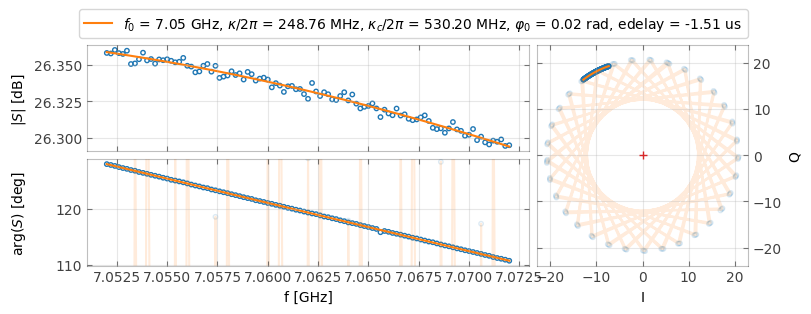

In [ ]:
from single_qubit_pyscrip_v1_3.s002_res_spec_ge import Resonator_onetone

START_FREQ = config['res_freq_ge'][qubit_idx]- 10  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 10   # [MHz]

STEPS = 101


config['res_gain_ge'][qubit_idx] = 0.2
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_freq_ge_mixer', config['res_freq_ge'][qubit_idx]),
                ('relax_delay', 1),
                ('cooling', False)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = await onetone.run(py_avg=1000, liveplot=True, solve_type='hm')

## update value ##
config['res_freq_ge'][qubit_idx] = round(fres[0]/1e6,4)
# onetone.saveLabber(qubit_idx, yoko_value=None)


In [9]:
from single_qubit_pyscrip_v1_3.s003a_qubit_flux_spec_ge import Qubit_Twotone_Flux

run_cfg = select_config_idx(config, qubit_idx)

cemter = 7320
SPAN = 400
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
# 87 = =, by super junior
START_FREQ = 3000 # [MHz]
STOP_FREQ = 6000 # [MHz]
STEPS = 501

Start_flux = -3
Stop_flux = 3
Steps_flux = 31
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)

config['nqz_qubit'] = 2
run_cfg.update([('steps', STEPS),
                ('res_freq_ge_mixer', config['res_freq_ge'][qubit_idx]),
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixe_freq',cemter),
                ('qubit_gain_ge', 0.8),
                ('res_gain_ge', 0.5),
                ('qubit_length_ge', 2.0),
                ('relax_delay',1),
                ('cooling', False),
                ('qubit_ch', 2)
                ])

spectrum_ge_flux = Qubit_Twotone_Flux(soc, soccfg, run_cfg)
await spectrum_ge_flux.liveplot_yoko(50, yoko_range, 'yoko_connect', mode='voltage')
# spectrum_ge_flux.saveLabber(qubit_idx, yoko_range, mode='voltage')

FigureWidget({
    'data': [{'colorscale': [[0.0, '#440154'], [0.1111111111111111, '#482878'],
                             [0.2222222222222222, '#3e4989'], [0.3333333333333333,
                             '#31688e'], [0.4444444444444444, '#26828e'],
                             [0.5555555555555556, '#1f9e89'], [0.6666666666666666,
                             '#35b779'], [0.7777777777777778, '#6ece58'],
                             [0.8888888888888888, '#b5de2b'], [1.0, '#fde725']],
              'showscale': True,
              'type': 'heatmap',
              'uid': '0a33c6d3-ab73-408a-b258-9efeeeb83527',
              'x': array([-3. , -2.8, -2.6, -2.4, -2.2, -2. , -1.8, -1.6, -1.4, -1.2, -1. , -0.8,
                          -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,
                           1.8,  2. ,  2.2,  2.4,  2.6,  2.8,  3. ]),
              'y': array([2999.99999971, 3005.9999988 , 3011.99999788, ..., 5987.99954378,
                          

YOKO sweep:   0%|          | 0/31 [00:00<?, ?it/s]

average count:   0%|          | 0/50 [00:00<?, ?it/s]

⚠️ Measurement interrupted at 15 averages


Traceback (most recent call last):
  File "c:\Users\QEL\anaconda3\envs\qickenv\lib\site-packages\IPython\core\interactiveshell.py", line 3548, in run_code
    await eval(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\QEL\AppData\Local\Temp\ipykernel_18900\965882533.py", line 33, in <module>
    await spectrum_ge_flux.liveplot_yoko(50, yoko_range, 'yoko_connect', mode='voltage')
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_3\s003a_qubit_flux_spec_ge.py", line 266, in liveplot_yoko
    figw.data[0].z[:, : idx + 1] = z_norm
ValueError: assignment destination is read-only


In [108]:
from single_qubit_pyscrip_v1_3.s002b_res_punchout_ge import SingleToneSpectroscopyPunchout

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_freq_ge_mixer', config['res_freq_ge'][qubit_idx]),
                ('relax_delay', 1),
                ('cooling', False)
                ])

START_FREQ = config['res_freq_ge'][qubit_idx]- 4  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 4   # [MHz]
STEPS_freq = 81

START_gain = 0.01  # [MHz]
STOP_gain = 0.15  # [MHz]
STEPS_gain = 51
run_cfg.update([('f_steps', STEPS_freq), ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
               ('g_steps', STEPS_gain), ('res_gain_ge', QickSweep1D('gainloop', START_gain, STOP_gain))])
punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
await punchout.run(py_avg=10, liveplot=True)
# punchout.saveLabber(qubit_idx)

FigureWidget({
    'data': [{'showscale': True,
              'type': 'heatmap',
              'uid': 'b9419d32-e23f-48a7-8b5a-b2f69d9bb168',
              'x': array([7048.40999851, 7048.50999813, 7048.60999775, 7048.70999737,
                          7048.80999699, 7048.9099966 , 7049.00999622, 7049.10999584,
                          7049.20999546, 7049.30999508, 7049.4099947 , 7049.50999432,
                          7049.60999393, 7049.70999355, 7049.80999317, 7049.90999279,
                          7050.00999241, 7050.10999203, 7050.20999165, 7050.30999126,
                          7050.40999088, 7050.5099905 , 7050.60999012, 7050.70998974,
                          7050.80998936, 7050.90998898, 7051.00998859, 7051.10998821,
                          7051.20998783, 7051.30998745, 7051.40998707, 7051.50998669,
                          7051.60998631, 7051.70998592, 7051.80998554, 7051.90998516,
                          7052.00998478, 7052.1099844 , 7052.20998402, 7052.30998363

average count:   0%|          | 0/10 [00:00<?, ?it/s]

⚠️ Measurement interrupted at 3 averages


In [122]:
from single_qubit_pyscrip_v1_3.s003_qubit_spec_ge import Qubit_Twotone

center = 4200
# center = round(cooling_freq['f12']*1e3,3)
SPAN = 100
START_FREQ = center - SPAN # [MHz]
STOP_FREQ = center + SPAN  # [MHz]

STEPS = 201

config['nqz_qubit'] = 2

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([('steps', STEPS), 
                ('res_freq_ge_mixer', config['res_freq_ge'][qubit_idx]),
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',center),
                ('qubit_gain_ge', 0.2),
                ('res_gain_ge', 0.3),
                ('qubit_length_ge', 5),
                ('relax_delay',1),
                ('cooling', False),  # Set to False for qubit spectroscopy
                ('qubit_ch',2)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = await spectrum_ge.run(100, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
# spectrum_ge.saveLabber(qubit_idx, yoko_value=None)

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': 'Amplitude',
              'type': 'scatter',
              'uid': '8b0de5f5-e7f0-43bc-b06b-3958e0f0b008',
              'x': array([4099.99999998, 4100.99999908, 4101.99999819, ..., 4297.99982248,
                          4298.99982159, 4299.99982069]),
              'y': array([0., 0., 0., ..., 0., 0., 0.])}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 30},
               'template': '...',
               'title': {'text': 'average: 0 / 100'},
               'xaxis': {'constrain': 'domain', 'title': {'text': 'Frequency (MHz)'}},
               'yaxis': {'constrain': 'domain', 'title': {'text': 'ADC units'}}}
})

average count:   0%|          | 0/100 [00:00<?, ?it/s]

⚠️ Measurement interrupted at 12 averages
